# Resource & Solar System Testing
Scratch notebook for tuning `ResourceConfig` values and verifying planet/system generation.

**Assumes** this notebook lives in `notebooks/` and the `simulation/` directory is one level up.
Adjust `sys.path` below if your layout differs.

In [1]:
import sys
sys.path.insert(0, '../simulation')

import numpy as np
import matplotlib.pyplot as plt

from resources import (
    ResourceType,
    ResourceConfig,
    DEFAULT_RESOURCE_CONFIGS,
    sample_distribution,
)
from solar_system import Planet, SolarSystem

## 1 — sample_distribution smoke-test

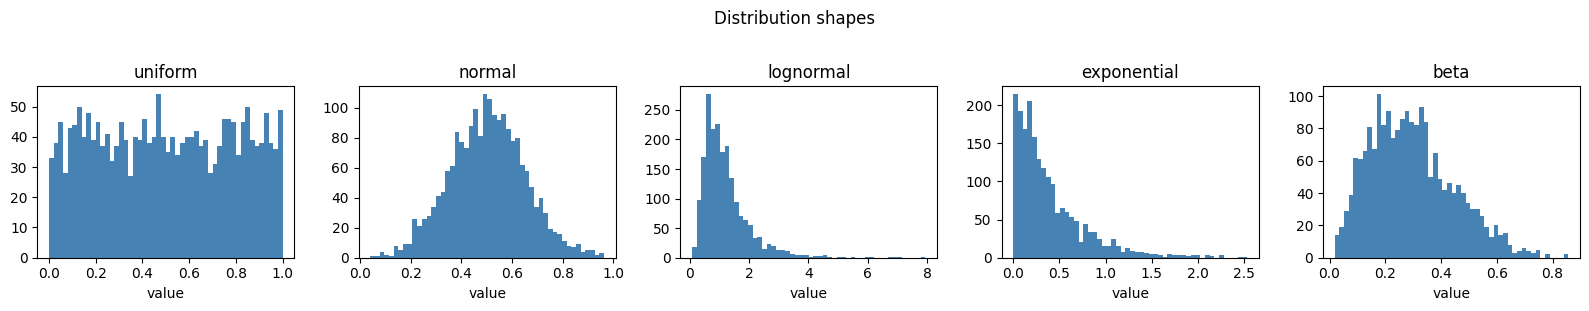

In [2]:
rng = np.random.default_rng(42)
n   = 2000

dists = {
    'uniform':     dict(dist='uniform',     low=0,   high=1),
    'normal':      dict(dist='normal',      mean=0.5, std=0.15),
    'lognormal':   dict(dist='lognormal',   mean=0,   std=0.6),
    'exponential': dict(dist='exponential', mean=0.4),
    'beta':        dict(dist='beta',        mean=0.3, std=0.15),
}

fig, axes = plt.subplots(1, len(dists), figsize=(16, 3))
for ax, (name, kwargs) in zip(axes, dists.items()):
    samples = sample_distribution(**kwargs, size=n, rng=rng)
    ax.hist(samples, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(name)
    ax.set_xlabel('value')
plt.suptitle('Distribution shapes', y=1.02)
plt.tight_layout()
plt.show()

## 2 — Single planet

In [3]:
p = Planet(size=5.0, quality=3.5, rng=np.random.default_rng(1))
print(p.summary())

  Planet  size=5.00  quality=3.5/5
    MINERALS        8832.72
    ENERGY           202.90
    ORGANICS         103.66
    RARE_MATS         14.82


## 3 — Single solar system

In [4]:
sys1 = SolarSystem(position=(0, 0, 0), n_planets=6, seed=1)
print(sys1.summary())

SolarSystem @ (0, 0, 0)  (6 planets)
  -- Planet 1 --
  Planet  size=9.62  quality=2.0/5
    MINERALS        7956.29
    ENERGY           108.59
    ORGANICS          47.95
    RARE_MATS          0.59
  -- Planet 2 --
  Planet  size=7.28  quality=3.1/5
    MINERALS        7487.51
    ENERGY           932.48
    ORGANICS         531.71
    RARE_MATS         17.05
  -- Planet 3 --
  Planet  size=5.46  quality=2.2/5
    MINERALS        2656.22
    ENERGY           371.87
    ORGANICS         155.01
    RARE_MATS          8.36
  -- Planet 4 --
  Planet  size=2.84  quality=1.6/5
    MINERALS        1581.25
    ENERGY            12.98
    ORGANICS          32.69
    RARE_MATS          2.19
  -- Planet 5 --
  Planet  size=1.69  quality=2.6/5
    MINERALS        1213.95
    ENERGY            91.69
    ORGANICS          37.14
    RARE_MATS          7.40
  -- Planet 6 --
  Planet  size=9.70  quality=1.2/5
    MINERALS        5233.80
    ENERGY           144.80
    ORGANICS         121.65
    RAR

## 4 — Resource distribution across many systems

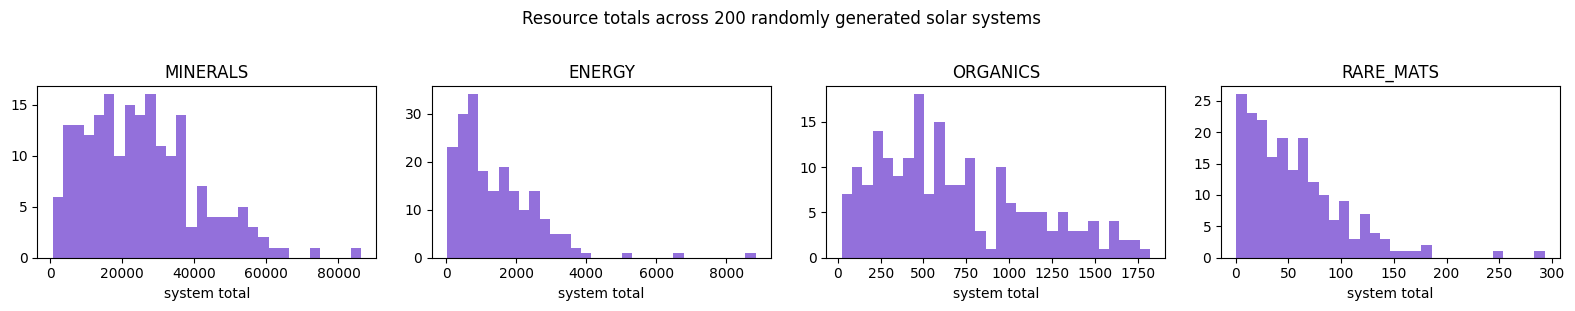

In [5]:
rng = np.random.default_rng(0)
N   = 200

systems = [
    SolarSystem(
        position=(rng.uniform(-100, 100), rng.uniform(-100, 100), rng.uniform(-100, 100)),
        n_planets=rng.integers(3, 9),
        seed=int(rng.integers(1e6)),
    )
    for _ in range(N)
]

# Aggregate totals per resource across all systems
totals = {r: [] for r in ResourceType}
for s in systems:
    for rtype, val in s.total_resources().items():
        totals[rtype].append(val)

fig, axes = plt.subplots(1, len(ResourceType), figsize=(16, 3))
for ax, rtype in zip(axes, ResourceType):
    ax.hist(totals[rtype], bins=30, color='mediumpurple', edgecolor='none')
    ax.set_title(rtype.name)
    ax.set_xlabel('system total')
plt.suptitle(f'Resource totals across {N} randomly generated solar systems', y=1.02)
plt.tight_layout()
plt.show()

## 5 — Config tuning sandbox
Override a single resource config and compare outputs.

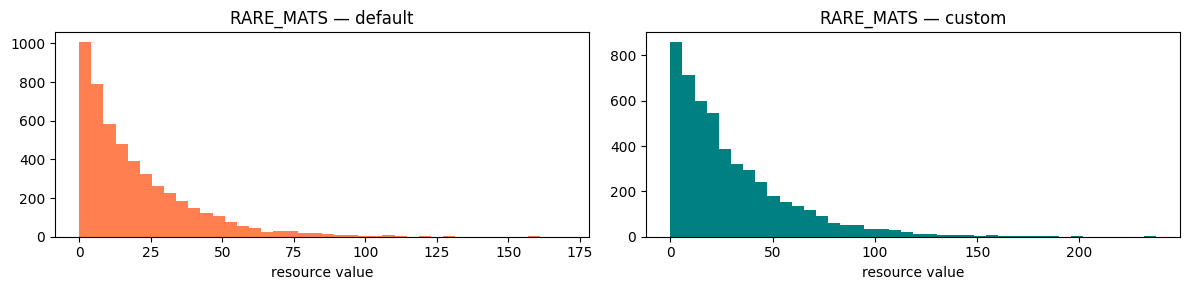

Default  mean=19.8  max=169.6
Custom   mean=30.2   max=237.3


In [6]:
import copy

# Start from defaults, tweak RARE_MATS
custom_configs = copy.deepcopy(DEFAULT_RESOURCE_CONFIGS)
custom_configs[ResourceType.RARE_MATS] = ResourceConfig(
    dist='exponential', mean=0.6, std=0.9, scale=50.0,
    size_exponent=0.8,  quality_exponent=2.5,
)

rng = np.random.default_rng(1)
rare_default = []
rare_custom  = []

for _ in range(5000):
    p_def = Planet(size=5.0, quality=3.0, rng=rng, resource_configs=DEFAULT_RESOURCE_CONFIGS)
    p_cus = Planet(size=5.0, quality=3.0, rng=rng, resource_configs=custom_configs)
    rare_default.append(p_def.resources[ResourceType.RARE_MATS])
    rare_custom.append(p_cus.resources[ResourceType.RARE_MATS])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
ax1.hist(rare_default, bins=40, color='coral');    ax1.set_title('RARE_MATS — default')
ax2.hist(rare_custom,  bins=40, color='teal');     ax2.set_title('RARE_MATS — custom')
for ax in (ax1, ax2):
    ax.set_xlabel('resource value')
plt.tight_layout()
plt.show()

print(f'Default  mean={np.mean(rare_default):.1f}  max={np.max(rare_default):.1f}')
print(f'Custom   mean={np.mean(rare_custom):.1f}   max={np.max(rare_custom):.1f}')